In [1]:
import pandas as pd
import os

# base_path = os.path.dirname(os.path.abspath(__file__))
# training_path = os.path.join(base_path, "Training.csv")

# training_path = pd.read_csv('Training.csv')

df = pd.read_csv('Training.csv')

# Print all symptom column names
symptoms = df.drop("prognosis", axis=1).columns.tolist()

print("Total Symptoms:", len(symptoms))
print(symptoms)

Total Symptoms: 132
['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_pain', 'weakness_in_limbs', 'fast_heart_rat

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("Training.csv")  # 👈 replace with your file

df1 = pd.read_csv("testing_dataset.csv")  # 👈 replace with your file

print(df.shape)
print(df1.shape)

print("Training columns:", df.columns.tolist())
print("Testing columns:", df1.columns.tolist())


# # Features & target
# X = df.drop("prognosis", axis=1)
# y = df["prognosis"]

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # Train model
# model = RandomForestClassifier(n_estimators=40, random_state=42)
# model.fit(X_train, y_train)






# # Features & target
# X = df.drop("prognosis", axis=1)
# y = df["prognosis"]

# # Split data
# X_train1, X_test1, y_train1, y_test1 = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # Predictions7
# y_pred1 = model.predict(X_test1)

# # # Accuracy
# accuracy = accuracy_score(y_test1, y_pred1)
# print("Accuracy:", accuracy)

# # # Classification report
# print("\nClassification Report:\n")
# # print(classification_report(y_test, y_pred))

(2460, 134)
(4920, 133)
Training columns: ['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_pain', 'weakness_in_l

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

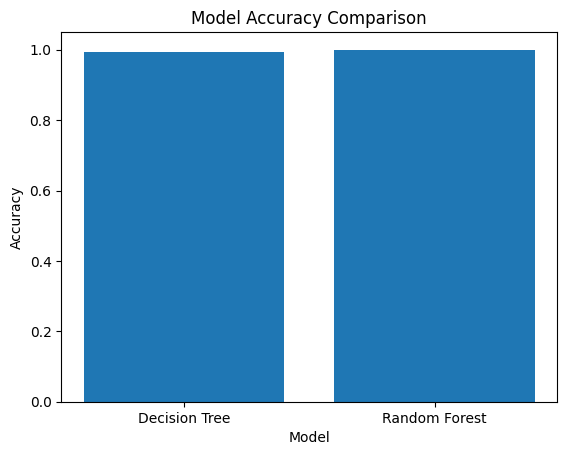

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Accuracy comparison
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy

models = ["Decision Tree", "Random Forest"]
accuracies = [dt_acc, rf_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ----------------------------
# 1. Load datasets
# ----------------------------
train_df = pd.read_csv("Training.csv")       # Training dataset
test_df = pd.read_csv("testing_dataset.csv") # Testing dataset

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

# ----------------------------
# 2. Preprocess datasets
# ----------------------------
# Drop first column if it's serial number
if train_df.columns[0].lower() in ["serial", "serialnumber", "sn", "unnamed: 0"]:
    train_df = train_df.drop(train_df.columns[0], axis=1)
if test_df.columns[0].lower() in ["serial", "serialnumber", "sn", "unnamed: 0"]:
    test_df = test_df.drop(test_df.columns[0], axis=1)

# Features & target
X_train = train_df.drop("prognosis", axis=1)
y_train = train_df["prognosis"]

X_test = test_df.drop("prognosis", axis=1)
y_test = test_df["prognosis"]

# ----------------------------
# 3. Align columns safely
# ----------------------------
# Add missing columns in test set
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0

# Remove extra columns from test set
X_test = X_test[X_train.columns]

# ----------------------------
# 4. Train model
# ----------------------------
model = RandomForestClassifier(n_estimators=40, random_state=42)
model.fit(X_train, y_train)

# ----------------------------
# 5. Predictions
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# 6. Evaluation
# ----------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy*100:.2f}%\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Training data shape: (4920, 133)
Testing data shape: (2460, 134)

Model Accuracy: 100.00%

Classification Report:

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        65
                                   AIDS       1.00      1.00      1.00        55
                                   Acne       1.00      1.00      1.00        52
                    Alcoholic hepatitis       1.00      1.00      1.00        56
                                Allergy       1.00      1.00      1.00        58
                              Arthritis       1.00      1.00      1.00        60
                       Bronchial Asthma       1.00      1.00      1.00        60
                   Cervical spondylosis       1.00      1.00      1.00        51
                            Chicken pox       1.00      1.00      1.00        57
                    Chronic cholestasis       1.00      1.00      1.00    